Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Fashion Classification Assessment**

---

### **Import Libraries**

In [138]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [139]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [140]:
train_data.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [141]:
train_data[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [142]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

In [143]:
train_data = train_data / 255.0
test_data = test_data / 255.0

train_data.min(), train_data.max()

(0.0, 1.0)

### **Create Model**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])  
# CHANGE PARAMETERS - STILL NOT ACCURATE 
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, 
                    epochs=20,
                    validation_data=(test_data, test_labels),
                    )

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


   1/1875 [..............................] - ETA: 37:41 - loss: 2.4266 - accuracy: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 12s 6ms/step - loss: 0.4968 - accuracy: 0.8254 - val_loss: 0.4276 - val_accuracy: 0.8433
Epoch 2/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3719 - accuracy: 0.8655 - val_loss: 0.4468 - val_accuracy: 0.8473
Epoch 3/20
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3355 - accuracy: 0.8775 - val_loss: 0.3796 - val_accuracy: 0.8634
Epoch 4/20
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3124 - accuracy: 0.8867 - val_loss: 0.3761 - val_accuracy: 0.8638
Epoch 5/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2938 - accuracy: 0.8912 - val_loss: 0.3717 - val_accuracy: 0.8673
Epoch 6/20
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2788 - accuracy: 0.8967 - val_loss: 0.3734 - val_accuracy: 0.8629
Epoch 7/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2666 - accuracy: 0.9017 - val_loss: 0.3553 - val_accuracy: 0.873

### **Display Results**

In [145]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    x_input = np.c_[xx.ravel(), yy.ravel()]
    
    y_pred = model.predict(x_input)
    
    if model.output_shape[-1] > 1: 
        print("doing multiclass classification...")
        
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print('doing binary classification...')
        y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)
        
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

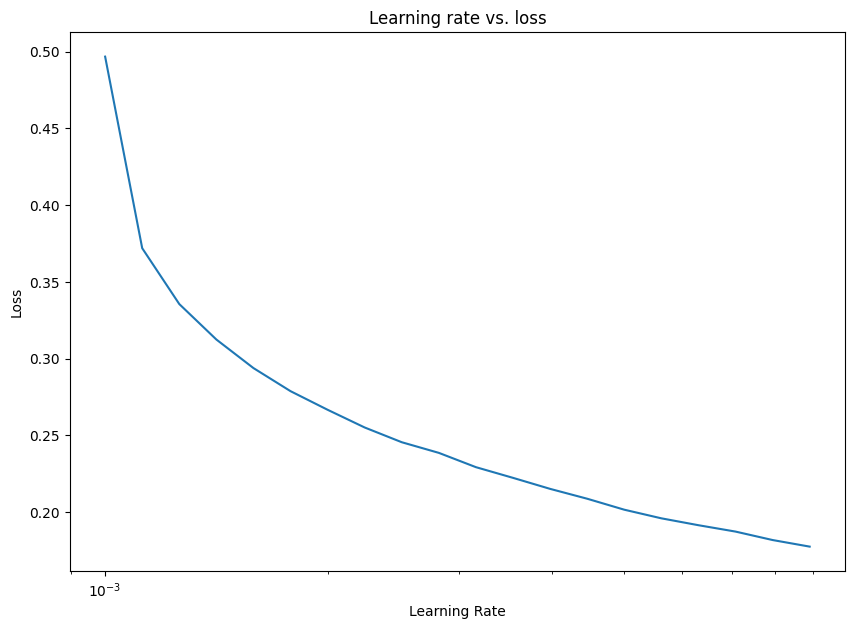

In [146]:
lrs = 0.001 * (10 ** (np.arange(20)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

Text(0, 0.5, 'Loss')

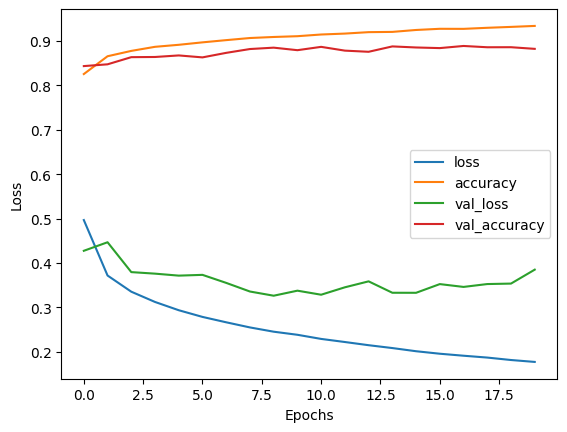

In [147]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')

In [148]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)

In [149]:
y_probs = model.predict(test_data)

y_probs[:5]

313/313 [==============================] - 1s 2ms/step


array([[1.79288040e-09, 1.70330262e-13, 1.32059341e-09, 2.89325291e-12,
        1.12678269e-10, 4.12968220e-04, 5.88517537e-07, 5.71286445e-03,
        7.64024719e-08, 9.93873477e-01],
       [3.38815116e-05, 8.37344479e-17, 9.98012185e-01, 6.05365497e-12,
        1.93495804e-03, 4.97964482e-17, 1.89459970e-05, 1.07654804e-13,
        6.95687485e-13, 6.36474617e-15],
       [1.06446509e-13, 1.00000000e+00, 9.84852752e-17, 2.43130169e-13,
        2.35781582e-13, 1.03825762e-23, 5.25026649e-16, 1.79122409e-26,
        9.31411121e-20, 3.22645546e-20],
       [4.40806905e-11, 1.00000000e+00, 1.03779175e-13, 2.62446065e-09,
        2.03305497e-11, 2.87860756e-18, 3.48209634e-12, 1.30604985e-20,
        1.06913260e-17, 2.74876125e-15],
       [3.37740511e-01, 4.58499594e-09, 1.55506504e-03, 2.47525113e-05,
        1.45154097e-03, 2.95114887e-07, 6.59227848e-01, 4.19293461e-10,
        1.77188024e-08, 1.17679244e-09]], dtype=float32)

In [150]:
y_probs[0].argmax(), class_names[y_probs[0].argmax()]

(9, 'Ankle boot')

In [151]:
y_preds = y_probs.argmax(axis=1)

y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [152]:
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[846,   2,  11,  22,  13,   2, 101,   0,   3,   0],
       [  2, 972,   3,  10,   9,   0,   3,   1,   0,   0],
       [ 13,   1, 740,   9, 180,   0,  57,   0,   0,   0],
       [ 19,   6,   7, 888,  53,   0,  23,   0,   4,   0],
       [  0,   0,  58,  16, 902,   0,  24,   0,   0,   0],
       [  0,   0,   0,   0,   0, 965,   0,  25,   2,   8],
       [126,   1,  81,  29, 122,   0, 637,   0,   4,   0],
       [  0,   0,   0,   0,   0,   6,   0, 981,   0,  13],
       [  4,   0,   6,   5,  10,   5,   9,   2, 959,   0],
       [  0,   0,   0,   0,   0,  10,   1,  58,   0, 931]])

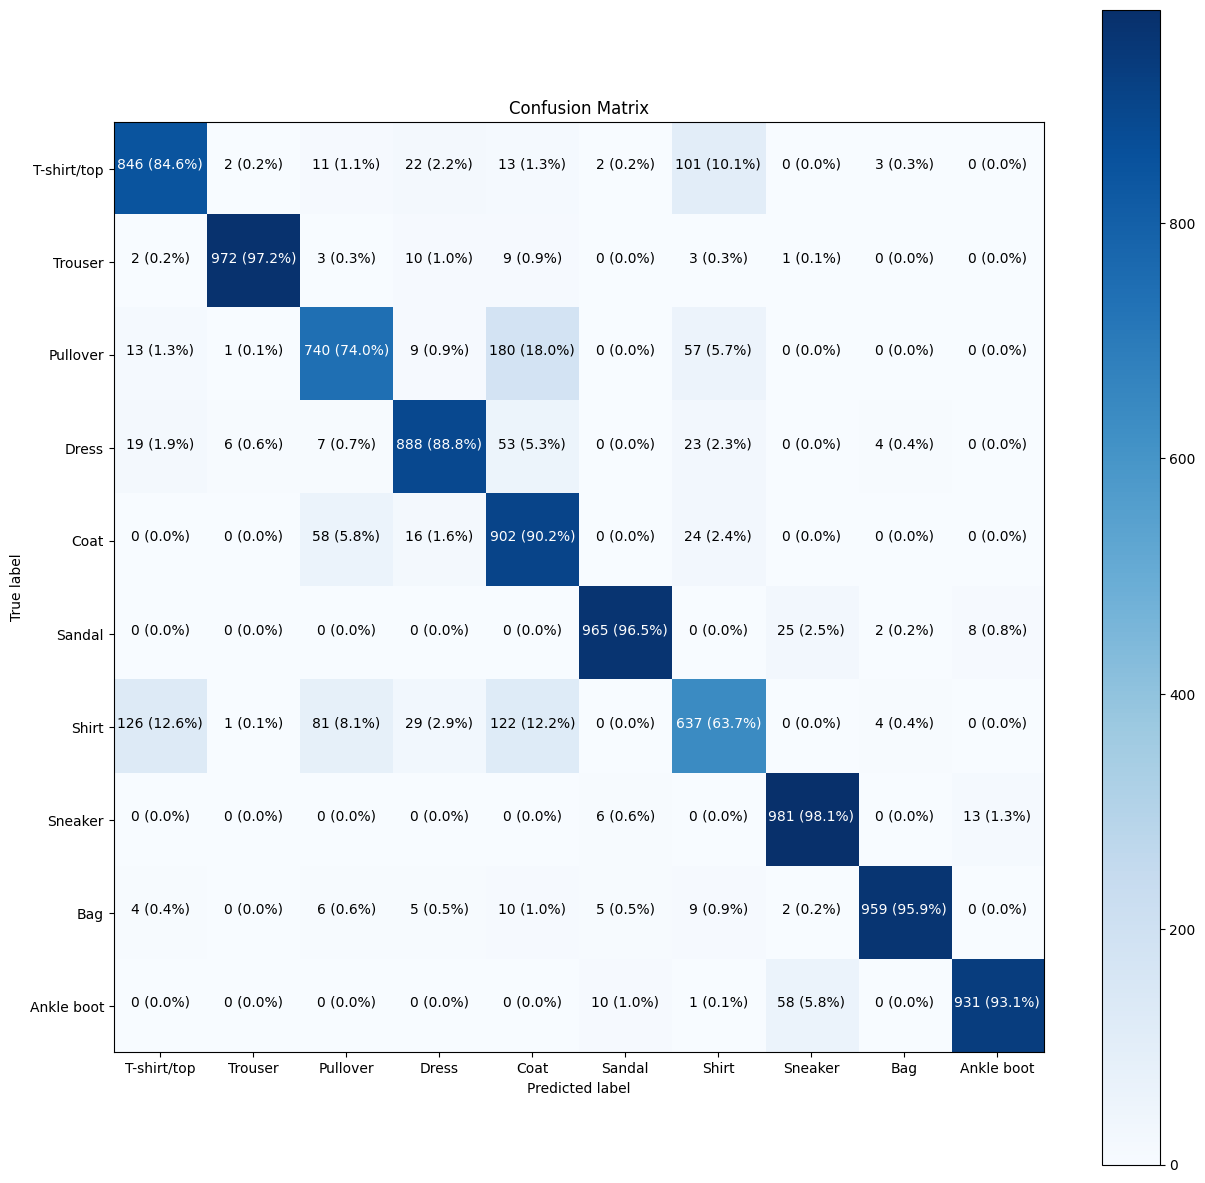

In [153]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10)

In [154]:
import random

# Create a function for plotting a random image along with its prediction
def plot_random_image(model, images, true_labels, classes):
  """Picks a random image, plots it and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: a set of random images (in tensor form).
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of a random image from `images` with a predicted class label from `model`
    as well as the truth class label from `true_labels`.
  """
  # Setup random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28)) # have to reshape to get into right size for model
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # set the color to green or red

1/1 [==============================] - 0s 23ms/step


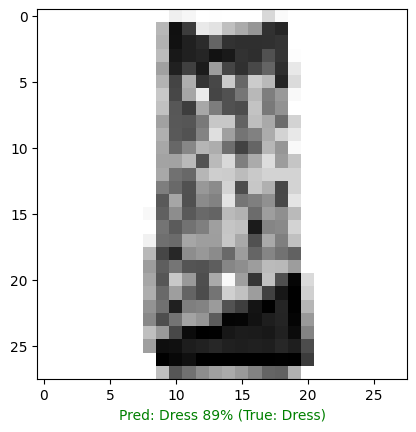

In [171]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)